# An?lise - M?tricas de Valida??o (U-Net vs RF)

**Objetivo:** Calcular m?tricas comparativas usando VAL_FINAL e mapas de predi??o.

**Entradas esperadas:**
- /content/drive/MyDrive/GEE_Exports/VAL_FINAL.geojson
- /content/drive/MyDrive/unet_preds_mt2023_v1/unet_mt2023_pred_c10.tif
- /content/drive/MyDrive/GEE_Exports/rf_milho_mask1_mt_2023_c10.tif

**Sa?das geradas:**
- metrics_valfinal_unet_vs_gt.json
- per_poly_valfinal_quick.csv
- table_metrics_valfinal_unet_vs_rf.csv

**Posi??o no fluxo:** Camada complementar de an?lise (n?o can?nica de produ??o).


In [ ]:
from pathlib import Path
import json
import numpy as np
import rasterio
from rasterio.mask import mask as rio_mask
from rasterio.warp import reproject, Resampling
from tqdm import tqdm

VAL_GEOJSON = Path("/content/drive/MyDrive/GEE_Exports/VAL_FINAL.geojson")

UNET_PRED_C10 = Path("/content/drive/MyDrive/unet_preds_mt2023_v1/unet_mt2023_pred_c10.tif")
RF_MAP = Path("/content/drive/MyDrive/GEE_Exports/rf_milho_mask1_mt_2023_c10.tif")

OUT_EVAL_DIR = Path("/content/drive/MyDrive/unet_preds_mt2023_v1/eval_valfinal")
OUT_EVAL_DIR.mkdir(parents=True, exist_ok=True)

assert VAL_GEOJSON.exists(), VAL_GEOJSON
assert UNET_PRED_C10.exists(), UNET_PRED_C10
assert RF_MAP.exists(), RF_MAP

print("ok paths")
print("val:", VAL_GEOJSON)
print("unet:", UNET_PRED_C10)
print("rf:", RF_MAP)
print("out:", OUT_EVAL_DIR)

ok paths
val: /content/drive/MyDrive/GEE_Exports/VAL_FINAL.geojson
unet: /content/drive/MyDrive/unet_preds_mt2023_v1/unet_mt2023_pred_c10.tif
rf: /content/drive/MyDrive/GEE_Exports/rf_milho_mask1_mt_2023_c10.tif
out: /content/drive/MyDrive/unet_preds_mt2023_v1/eval_valfinal


In [ ]:
def load_val_features_geojson(path: Path):
    obj = json.loads(path.read_text(encoding="utf-8"))
    feats = []
    for f in obj.get("features", []):
        props = f.get("properties", {}) or {}
        geom = f.get("geometry", None)
        if geom is None:
            continue
        if "class" not in props:
            continue
        cls = int(props["class"])
        fid = props.get("id", None)
        feats.append({"id": fid, "class": cls, "geometry": geom})
    return feats

val_feats = load_val_features_geojson(VAL_GEOJSON)

hist = {0: 0, 1: 0}
for f in val_feats:
    hist[int(f["class"])] = hist.get(int(f["class"]), 0) + 1

print("val feats:", len(val_feats))
print("class hist:", hist)

with rasterio.open(UNET_PRED_C10) as ds:
    print("unet crs:", ds.crs, "shape:", (ds.height, ds.width), "dtype:", ds.dtypes, "nodata:", ds.nodata)

with rasterio.open(RF_MAP) as ds:
    print("rf crs:", ds.crs, "shape:", (ds.height, ds.width), "dtype:", ds.dtypes, "nodata:", ds.nodata)

val feats: 269
class hist: {0: 151, 1: 118}
unet crs: EPSG:4326 shape: (48240, 48240) dtype: ('uint8',) nodata: 255.0
rf crs: EPSG:4326 shape: (39678, 42334) dtype: ('uint8',) nodata: None


In [ ]:
def cm_add(cm, gt, pr):
    # gt/pr são vetores uint8 só com 0/1
    gt1 = (gt == 1)
    pr1 = (pr == 1)
    tp = int(np.sum(gt1 & pr1))
    fp = int(np.sum((~gt1) & pr1))
    fn = int(np.sum(gt1 & (~pr1)))
    tn = int(np.sum((~gt1) & (~pr1)))
    cm["TP"] += tp
    cm["FP"] += fp
    cm["FN"] += fn
    cm["TN"] += tn
    cm["valid_pixels"] += int(gt.shape[0])

def cm_metrics(cm):
    tp, fp, fn, tn = cm["TP"], cm["FP"], cm["FN"], cm["TN"]
    denom_iou = tp + fp + fn
    denom_f1 = 2*tp + fp + fn
    prec = tp / (tp + fp + 1e-9)
    rec  = tp / (tp + fn + 1e-9)
    f1   = (2*tp) / (denom_f1 + 1e-9)
    iou  = tp / (denom_iou + 1e-9)
    acc  = (tp + tn) / (tp + fp + fn + tn + 1e-9)
    return {
        "precision": float(prec),
        "recall": float(rec),
        "f1": float(f1),
        "iou_pos": float(iou),
        "acc": float(acc),
        "TP": int(tp), "FP": int(fp), "FN": int(fn), "TN": int(tn),
        "valid_pixels": int(cm["valid_pixels"]),
    }

In [ ]:
cm_unet = {"TP":0, "FP":0, "FN":0, "TN":0, "valid_pixels":0}
cm_rf   = {"TP":0, "FP":0, "FN":0, "TN":0, "valid_pixels":0}

per_poly = []

with rasterio.open(UNET_PRED_C10) as unet_ds, rasterio.open(RF_MAP) as rf_ds:
    # tudo em epsg:4326; rf pode estar em grade diferente, então sempre reproject para a grade do unet recortado
    for f in tqdm(val_feats, total=len(val_feats), desc="eval VAL_FINAL"):
        geom = f["geometry"]
        cls = int(f["class"])

        # recorta unet na geometria; fora da geometria vira 255; dentro fora do c10 também é 255
        unet_crop, unet_tr = rio_mask(
            unet_ds, [geom], crop=True, filled=True, nodata=255
        )
        unet_arr = unet_crop[0].astype(np.uint8)

        # recorta rf e reamostra para a mesma grade do unet_crop
        rf_crop, rf_tr = rio_mask(
            rf_ds, [geom], crop=True, filled=True, nodata=255
        )
        rf_src = rf_crop[0].astype(np.uint8)

        rf_dst = np.full_like(unet_arr, 255, dtype=np.uint8)
        reproject(
            source=rf_src,
            destination=rf_dst,
            src_transform=rf_tr,
            src_crs=rf_ds.crs,
            dst_transform=unet_tr,
            dst_crs=unet_ds.crs,
            resampling=Resampling.nearest,
            src_nodata=255,
            dst_nodata=255
        )

        # válidos: só onde unet tem 0/1 (dentro c10 e dentro do polígono)
        valid = (unet_arr != 255) & (rf_dst != 255)
        n_valid = int(valid.sum())
        if n_valid == 0:
            continue

        gt = np.full(n_valid, cls, dtype=np.uint8)
        pr_unet = unet_arr[valid].astype(np.uint8)
        pr_rf = rf_dst[valid].astype(np.uint8)

        # força binário (seguro)
        pr_unet = (pr_unet == 1).astype(np.uint8)
        pr_rf   = (pr_rf == 1).astype(np.uint8)

        cm_add(cm_unet, gt, pr_unet)
        cm_add(cm_rf, gt, pr_rf)

        per_poly.append({
            "id": f.get("id", None),
            "class": cls,
            "valid_pixels": n_valid,
            "unet_pred_pos_frac": float(pr_unet.mean()),
            "rf_pred_pos_frac": float(pr_rf.mean()),
        })

print("done")
print("unet:", cm_metrics(cm_unet))
print("rf  :", cm_metrics(cm_rf))

eval VAL_FINAL: 100%|██████████| 269/269 [00:06<00:00, 43.87it/s] 


done
unet: {'precision': 0.9823243130268571, 'recall': 0.9929678068410414, 'f1': 0.9876173846915829, 'iou_pos': 0.9755376769194227, 'acc': 0.9884308491990386, 'TP': 197402, 'FP': 3552, 'FN': 1398, 'TN': 225510, 'valid_pixels': 427862}
rf  : {'precision': 0.9803697218131842, 'recall': 0.991297786720317, 'f1': 0.9858034695960117, 'iou_pos': 0.9720043798644562, 'acc': 0.9867340404148979, 'TP': 197070, 'FP': 3946, 'FN': 1730, 'TN': 225116, 'valid_pixels': 427862}


In [ ]:
import pandas as pd

out = {
    "val_features": int(len(val_feats)),
    "unet": cm_metrics(cm_unet),
    "rf": cm_metrics(cm_rf),
}

(OUT_EVAL_DIR / "metrics_valfinal_unet_vs_gt.json").write_text(json.dumps(out, indent=2), encoding="utf-8")
pd.DataFrame(per_poly).to_csv(OUT_EVAL_DIR / "per_poly_valfinal_quick.csv", index=False)

print("salvo:")
print(" -", OUT_EVAL_DIR / "metrics_valfinal_unet_vs_gt.json")
print(" -", OUT_EVAL_DIR / "per_poly_valfinal_quick.csv")

salvo:
 - /content/drive/MyDrive/unet_preds_mt2023_v1/eval_valfinal/metrics_valfinal_unet_vs_gt.json
 - /content/drive/MyDrive/unet_preds_mt2023_v1/eval_valfinal/per_poly_valfinal_quick.csv


In [ ]:
import pandas as pd
from pathlib import Path
import json

OUT_EVAL_DIR = Path("/content/drive/MyDrive/unet_preds_mt2023_v1/eval_valfinal")
j = json.loads((OUT_EVAL_DIR / "metrics_valfinal_unet_vs_gt.json").read_text(encoding="utf-8"))

rows = []
for m in ["unet", "rf"]:
    r = j[m]
    rows.append({
        "model": m.upper(),
        "precision": r["precision"],
        "recall": r["recall"],
        "f1": r["f1"],
        "iou_pos": r["iou_pos"],
        "acc": r["acc"],
        "TP": r["TP"], "FP": r["FP"], "FN": r["FN"], "TN": r["TN"],
        "valid_pixels": r["valid_pixels"],
    })

df = pd.DataFrame(rows)
df["precision"] = df["precision"].map(lambda x: round(x, 6))
df["recall"] = df["recall"].map(lambda x: round(x, 6))
df["f1"] = df["f1"].map(lambda x: round(x, 6))
df["iou_pos"] = df["iou_pos"].map(lambda x: round(x, 6))
df["acc"] = df["acc"].map(lambda x: round(x, 6))

out_csv = OUT_EVAL_DIR / "table_metrics_valfinal_unet_vs_rf.csv"
df.to_csv(out_csv, index=False)
df

,model,precision,recall,f1,iou_pos,acc,TP,FP,FN,TN,valid_pixels
0,UNET,0.982324,0.992968,0.987617,0.975538,0.988431,197402,3552,1398,225510,427862
1,RF,0.980370,0.991298,0.985803,0.972004,0.986734,197070,3946,1730,225116,427862


salvo: /content/drive/MyDrive/unet_preds_mt2023_v1/eval_valfinal/fig_metrics_valfinal_unet_vs_rf.png


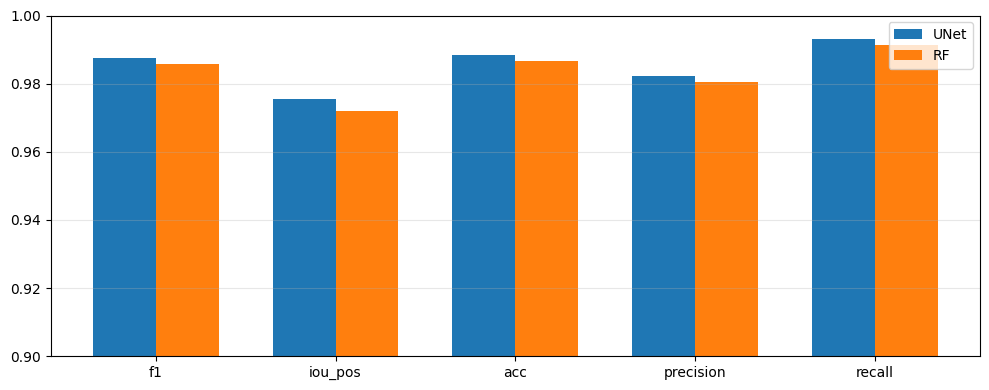

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import pandas as pd

OUT_EVAL_DIR = Path("/content/drive/MyDrive/unet_preds_mt2023_v1/eval_valfinal")
df = pd.read_csv(OUT_EVAL_DIR / "table_metrics_valfinal_unet_vs_rf.csv")

metrics = ["f1", "iou_pos", "acc", "precision", "recall"]
x = np.arange(len(metrics))
w = 0.35

unet = df[df["model"]=="UNET"].iloc[0]
rf = df[df["model"]=="RF"].iloc[0]

plt.figure(figsize=(10,4))
plt.bar(x - w/2, [unet[m] for m in metrics], width=w, label="UNet")
plt.bar(x + w/2, [rf[m] for m in metrics], width=w, label="RF")
plt.xticks(x, metrics)
plt.ylim(0.9, 1.0)
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
out_png = OUT_EVAL_DIR / "fig_metrics_valfinal_unet_vs_rf.png"
plt.tight_layout()
plt.savefig(out_png, dpi=200)
print("salvo:", out_png)


In [ ]:
from pathlib import Path
import json

OUT_EVAL_DIR = Path("/content/drive/MyDrive/unet_preds_mt2023_v1/eval_valfinal")
j = json.loads((OUT_EVAL_DIR / "metrics_valfinal_unet_vs_gt.json").read_text(encoding="utf-8"))

u, r = j["unet"], j["rf"]
delta = {
  "f1": u["f1"]-r["f1"],
  "iou": u["iou_pos"]-r["iou_pos"],
  "acc": u["acc"]-r["acc"],
  "prec": u["precision"]-r["precision"],
  "rec": u["recall"]-r["recall"],
}

md = f"""## Avaliação (VAL_FINAL) — MT 2023 (máscara C10)

Avaliação pixel-a-pixel dentro dos polígonos VAL_FINAL (classes 0=não-milho, 1=milho), recortando e alinhando os mapas finais na mesma referência espacial (EPSG:4326) e ignorando pixels fora da máscara agrícola (nodata=255).

**UNet:** F1={u["f1"]:.4f}, IoU={u["iou_pos"]:.4f}, Precisão={u["precision"]:.4f}, Revocação={u["recall"]:.4f}, Acurácia={u["acc"]:.4f} (TP={u["TP"]}, FP={u["FP"]}, FN={u["FN"]}, TN={u["TN"]}, pixels válidos={u["valid_pixels"]}).

**RF:** F1={r["f1"]:.4f}, IoU={r["iou_pos"]:.4f}, Precisão={r["precision"]:.4f}, Revocação={r["recall"]:.4f}, Acurácia={r["acc"]:.4f} (TP={r["TP"]}, FP={r["FP"]}, FN={r["FN"]}, TN={r["TN"]}, pixels válidos={r["valid_pixels"]}).

Diferença (UNet − RF): ΔF1={delta["f1"]:.4f}, ΔIoU={delta["iou"]:.4f}, ΔAcc={delta["acc"]:.4f}.
"""
out_md = OUT_EVAL_DIR / "resultados_valfinal_unet_vs_rf.md"
out_md.write_text(md, encoding="utf-8")
print("salvo:", out_md)

salvo: /content/drive/MyDrive/unet_preds_mt2023_v1/eval_valfinal/resultados_valfinal_unet_vs_rf.md
